In [54]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from typing import Tuple
from datetime import datetime

#add path path to data folder using sys.path
sys.path.append('data_process/')

from data_process import load_dataset
from processors.demographics import get_demographics_data, get_demographic_summary, print_demographic_summary
from processors.measurements import get_bmi_data, get_bmi_statistics
from processors.cbc import get_cbc_data, get_cbc_subject_statistics, get_cbc_overall_statistics, CBC_REFERENCE_INTERVALS, remove_outliers


import matplotlib.pyplot as plt
import matplotlib.font_manager
import seaborn as sns

palette = sns.husl_palette(h=.7)
rc = {
    'figure.dpi': 300,
    'font.size': 6,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 6,  
    'legend.fontsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.edgecolor': 'k',
    'axes.linewidth': 0.5,
    'axes.grid': False,
    'axes.prop_cycle': plt.cycler(color=sns.husl_palette(h=.7)),
    'figure.figsize': (7, 2),
    'xtick.major.pad': -3,
    'ytick.major.pad': -3
}

plt.rcParams.update(rc)  # Apply the style
sns.set_theme(style="white", font='Arial', rc=rc)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
pwd

UsageError: CWD no longer exists - please use %cd to change directory.


In [31]:
# Load your data only if not already loaded
if 'df' not in locals():
    df = pd.read_csv('data/combined_subject_cbc_events.csv')
    print("Loading data...")
else:
    print("Data already loaded")

Data already loaded


In [32]:
def analyze_variable(df: pd.DataFrame, variable: str):
    """
    Analyze a single variable with two side-by-side plots:
    1. Distribution for all events
    2. Distribution for patient-level averages
    """
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2)
    
    if pd.api.types.is_numeric_dtype(df[variable]):
        # Get statistics for all events
        all_stats = df[variable].describe()
        
        # Get patient-level averages
        patient_means = df.groupby('subject_id')[variable].mean()
        patient_stats = patient_means.describe()
        
        # Left plot: All events
        sns.histplot(data=df, x=variable, ax=ax1)
        ax1.axvline(all_stats['mean'], color='black', linestyle='--', alpha=0.8, 
                    label=f'Mean: {all_stats["mean"]:.1f}', linewidth=1)
        ax1.axvline(all_stats['50%'], color='grey', linestyle='--', alpha=0.8, 
                    label=f'Median: {all_stats["50%"]:.1f}', linewidth=1)
        ax1.set_title('Event-Level')
        ax1.legend(loc='upper left')
        
        # Right plot: Patient-level averages
        sns.histplot(data=patient_means, ax=ax2, color=palette[2])
        ax2.axvline(patient_stats['mean'], color='black', linestyle='--', alpha=0.8,
                    label=f'Mean: {patient_stats["mean"]:.1f}', linewidth=1)
        ax2.axvline(patient_stats['50%'], color='grey', linestyle='--', alpha=0.8,
                    label=f'Median: {patient_stats["50%"]:.1f}', linewidth=1)
        ax2.set_title('Patient-Level (Average)')
        ax2.legend(loc='upper left')
        
    else:
        # For categorical variables
        # Left plot: All events
        all_counts = df[variable].value_counts()
        total_events = len(df)
        
        sns.barplot(x=all_counts.index, y=all_counts.values, ax=ax1)
        ax1.set_title('Event-Level')
        
        # Add percentage labels
        for i, v in enumerate(all_counts.values):
            percentage = 100 * v / total_events
            ax1.text(i, v, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=4)
        
        # Right plot: Most frequent value per patient
        # For categorical variables, use mode instead of mean
        patient_modes = df.groupby('subject_id')[variable].agg(lambda x: x.mode()[0])
        patient_counts = patient_modes.value_counts()
        total_patients = len(patient_modes)
        
        sns.barplot(x=patient_counts.index, y=patient_counts.values, ax=ax2, color=palette[2])
        ax2.set_title('Patient-Level (Mode)')
        
        # Add percentage labels
        for i, v in enumerate(patient_counts.values):
            percentage = 100 * v / total_patients
            ax2.text(i, v, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=4)
    
    # Common settings for both plots
    for ax in [ax1, ax2]:
        plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
        #ax.set_xlabel('')
        #ax.set_ylabel('')
       
    if variable == 'numeric_value':
        variable = df['code'].unique()[0]
    if variable == 'BMI_category':
        variable = 'BMI Category'
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
   # fig.suptitle(f'{variable} Distribution', fontsize = 8) # bolded title
    plt.tight_layout()
    return fig, (ax1, ax2)
    


Demographic Analysis


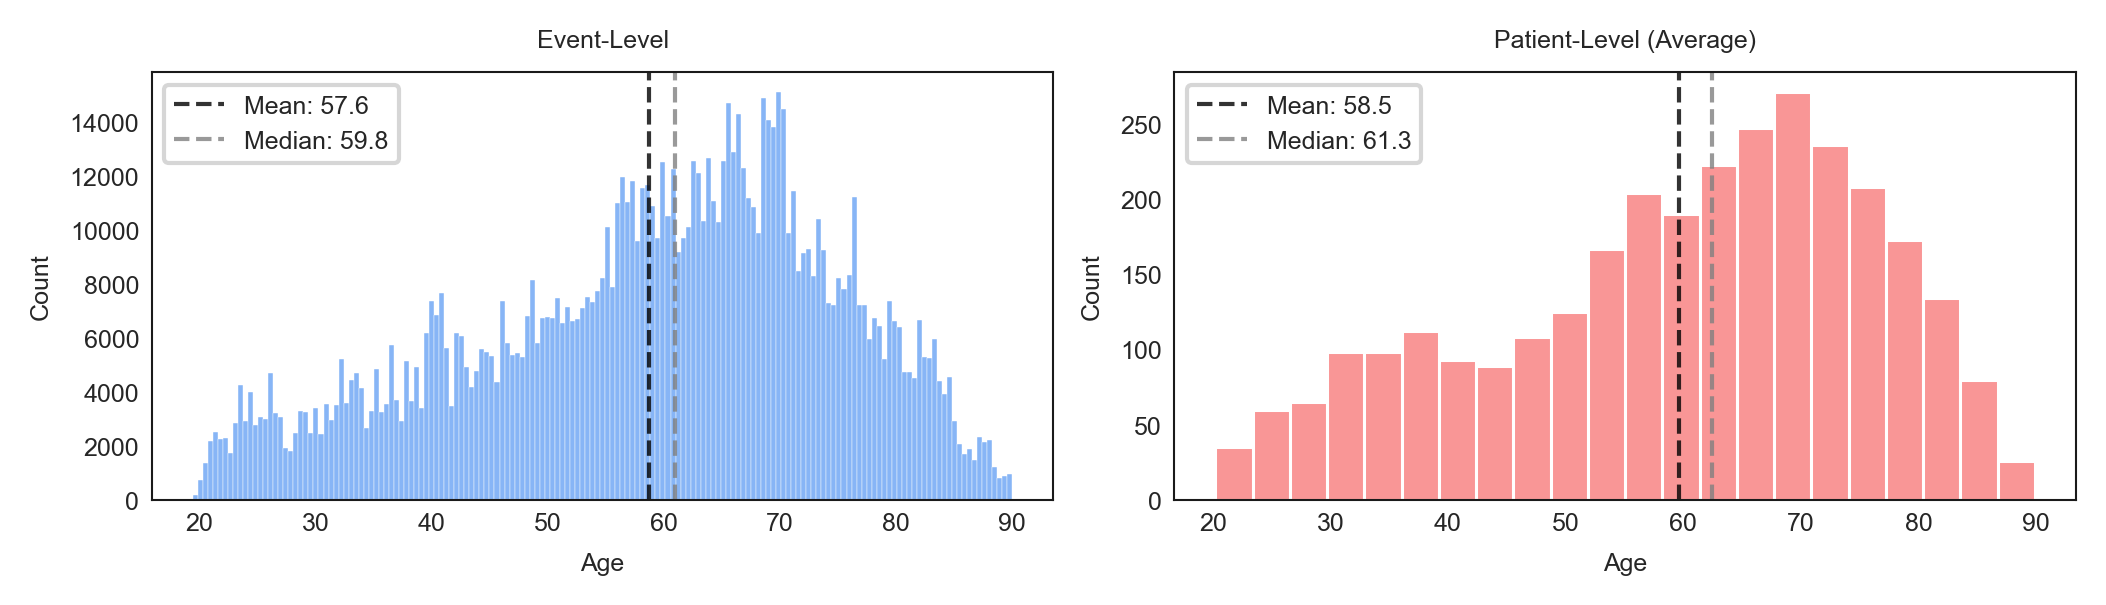

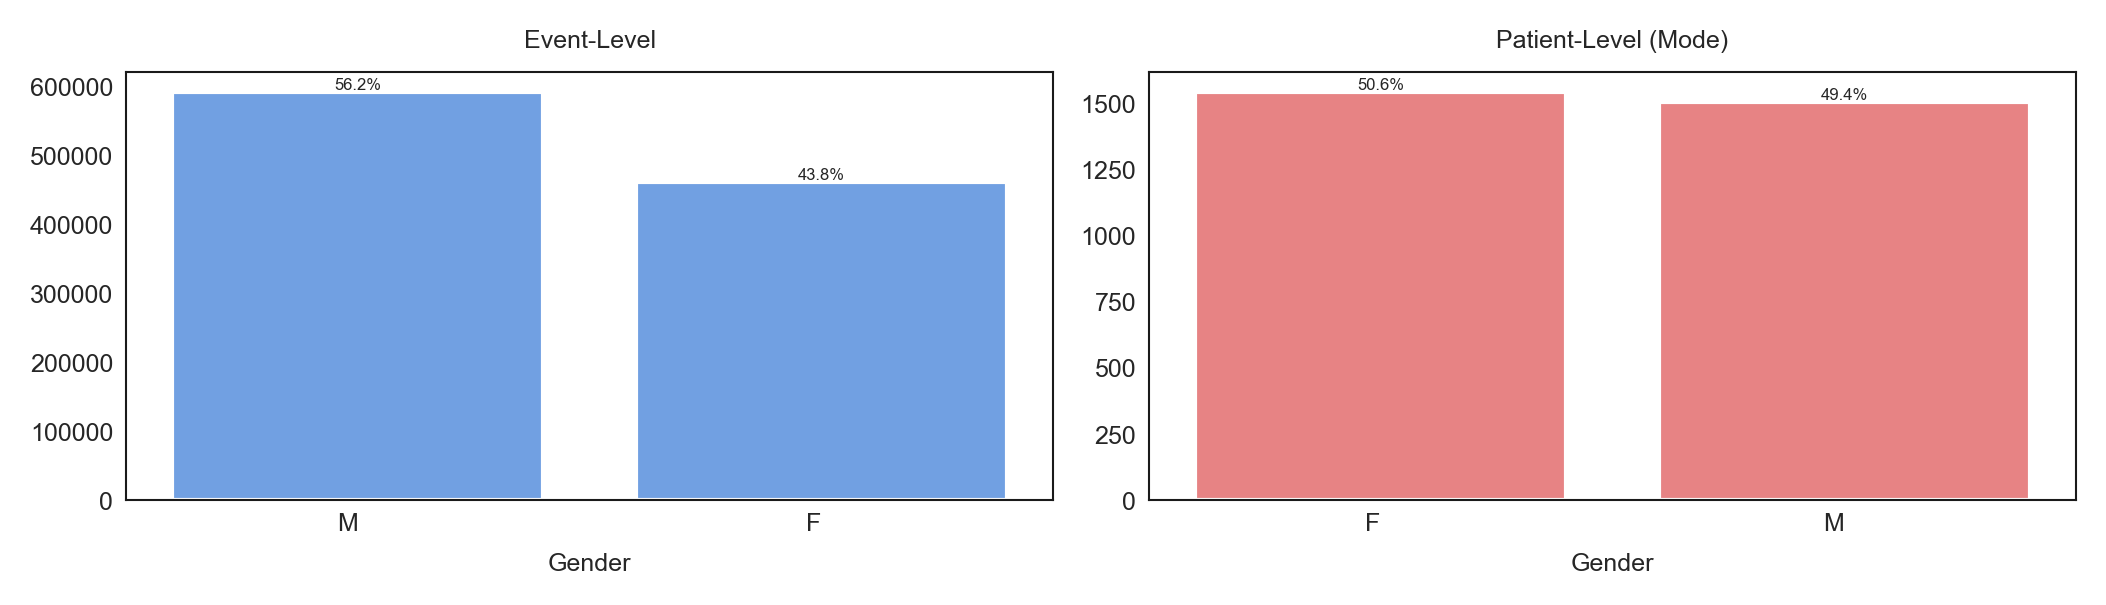

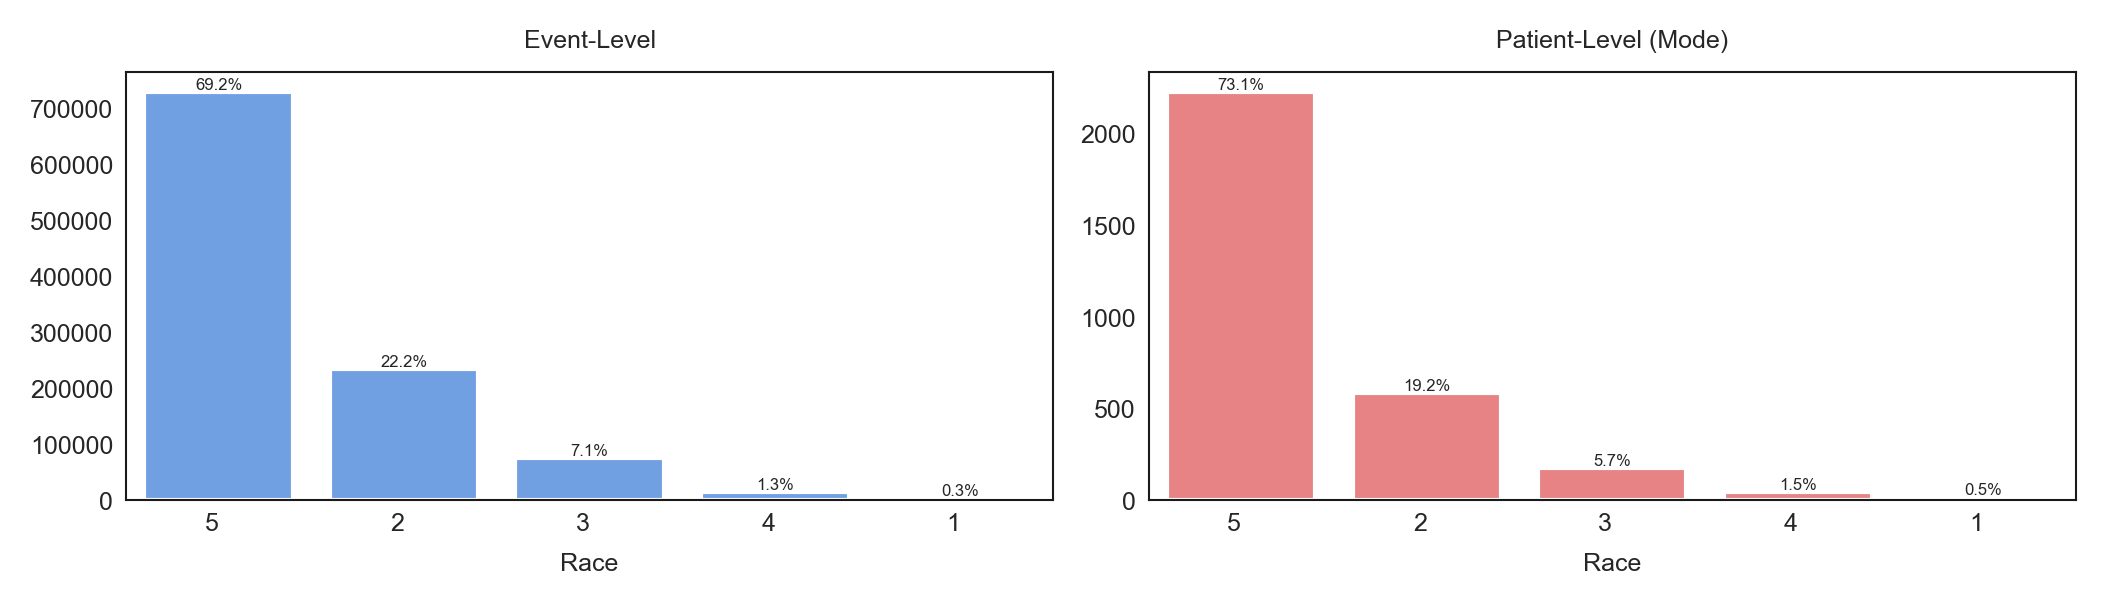

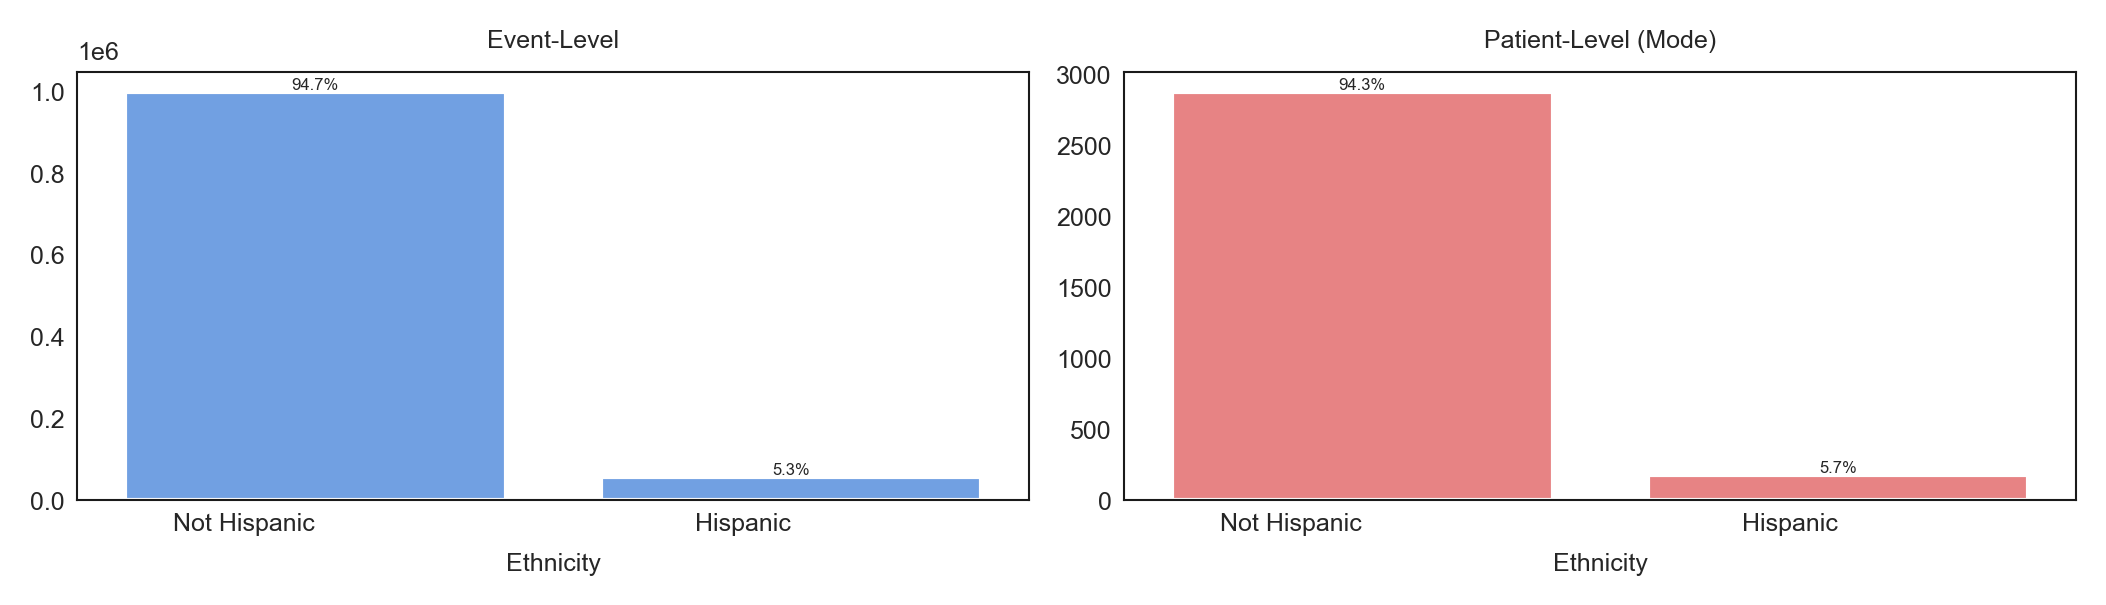

In [33]:

# Demographic analysis
print("\nDemographic Analysis")
for feature in ['Age', 'Gender', 'Race', 'Ethnicity']:
    df['Race'] = df['Race'].astype(str)
    
    fig, (ax1, ax2) = analyze_variable(df, feature)
    plt.show()


BMI Analysis


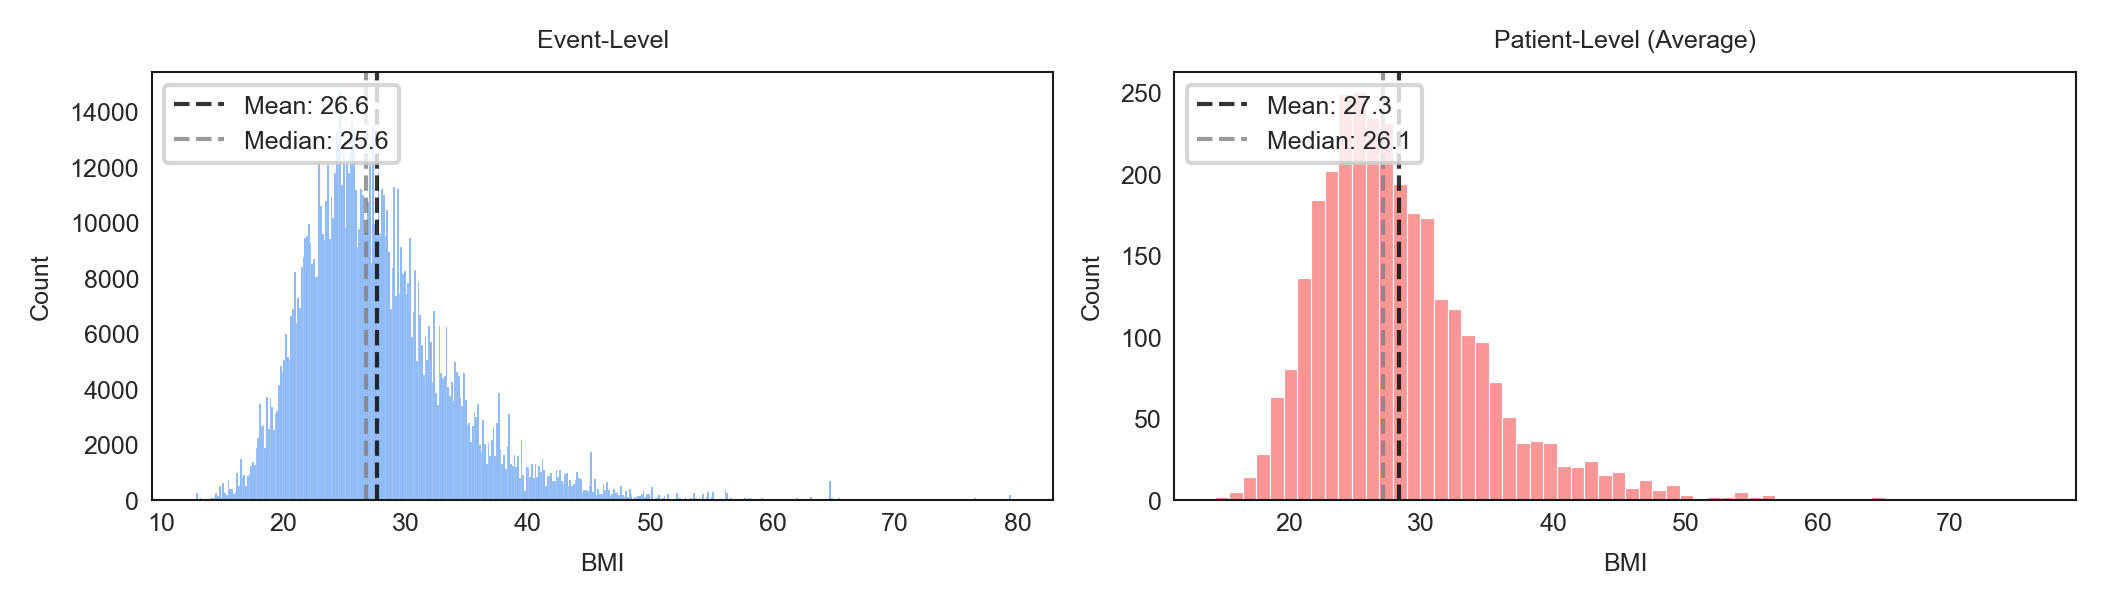

/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_6165/1267771104.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_6165/1267771104.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_6165/4151051832.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_6165/4151051832.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

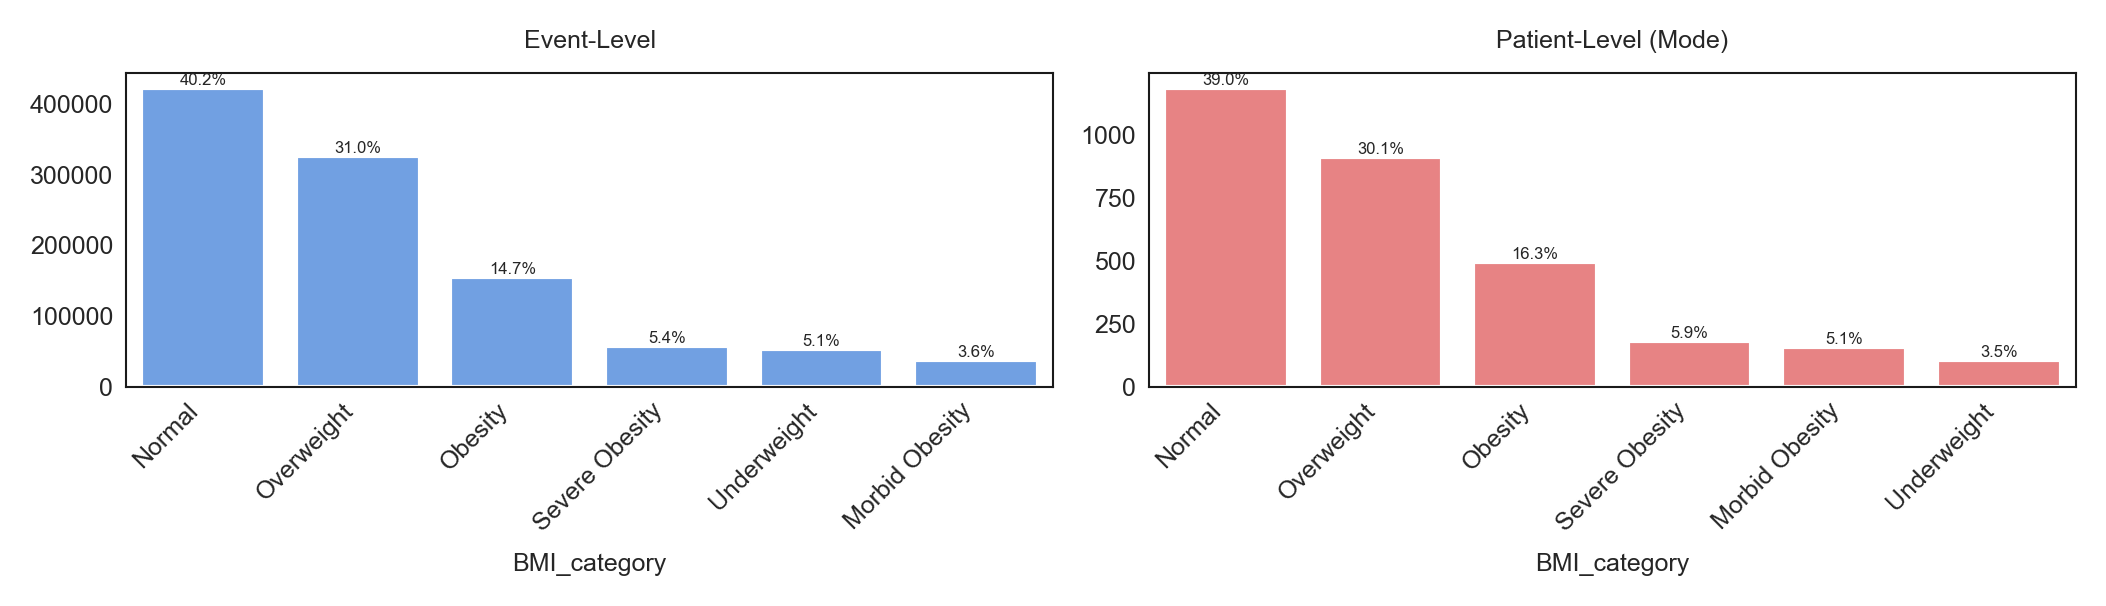

In [9]:
print("\nBMI Analysis")
for feature in ['BMI', 'BMI_category']:
    df['Race'] = df['Race'].astype(str)
    fig, (ax1, ax2) = analyze_variable(df, feature)
    if feature == 'BMI_category':
        # Rotate the x-axis labels
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    plt.show()

In [52]:

cbc_subject_stats = pd.read_csv('results/summary_statistics/cbc_subject_statistics.csv')
cbc_subject_stats

setpoint_df = pd.read_csv('results/setpoint_calculations/setpoints_gap:30_tests:5.csv')
display(setpoint_df.head())

demographics_df = pd.read_csv('data/processed/demographics.csv')

merged = pd.merge(setpoint_df, cbc_subject_stats, on=['subject_id', 'code'], how='left')
setpoint_df = pd.merge(merged, demographics_df, on='subject_id', how='left')
setpoint_df.percentage_tests_within_reference = setpoint_df.percentage_tests_within_reference.str.rstrip('%').astype(float)

display(merged.head())

,subject_id,code,setpoint,uncertainty,model_type
0,115967104,HCT,35.675000,0.025796,gmm
1,115967104,HGB,11.966667,0.010423,gmm
2,115967104,MCH,28.350000,0.006359,gmm
3,115967104,MCHC,33.174967,0.019811,gmm
4,115967104,MCV,84.725001,0.015054,gmm


,subject_id,code,setpoint,uncertainty,model_type,num_tests_taken,num_tests_within_reference,percentage_tests_within_reference,days_between_first_and_last,avg_days_between_tests,min_days_between_tests,max_days_between_tests
0,115967104,HCT,35.675000,0.025796,gmm,5,2,40.00%,7590,1897.62,30.78,6678.71
1,115967104,HGB,11.966667,0.010423,gmm,5,3,60.00%,7590,1897.62,30.78,6678.71
2,115967104,MCH,28.350000,0.006359,gmm,5,5,100.00%,7590,1897.62,30.78,6678.71
3,115967104,MCHC,33.174967,0.019811,gmm,5,5,100.00%,7590,1897.62,30.78,6678.71
4,115967104,MCV,84.725001,0.015054,gmm,5,5,100.00%,7590,1897.62,30.78,6678.71


In [124]:
def plot_distribution_with_statistics(data, gender_idx, ax, color=None, title='', ylabel='Count', is_setpoint=False):
    """
    Creates a histogram with mean and median lines, and optionally reference intervals.
    """
    # Get statistics
    stats = data.describe()
    
    # Create histogram
    plot_args = {'data': data} if gender_idx == 0 else {'data': data, 'color': palette[2]}
    sns.histplot(ax=ax, **plot_args)
    
    # Add mean and median lines
    ax.axvline(stats['mean'], color='black', linestyle='--', alpha=0.8,
               label=f'Mean: {stats["mean"]:.1f}', linewidth=1)
    ax.axvline(stats['50%'], color='grey', linestyle='--', alpha=0.8,
               label=f'Median: {stats["50%"]:.1f}', linewidth=1)
    
    # Set labels and title
    if gender_idx == 1:
        title = title.split('\n \n')[1]
        
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left')

def get_gender_data(df, setpoint_df, gender, variable, code):
    """
    Gets filtered data for a specific gender.
    """
    gender_df = df[df['Gender'] == gender].copy()
    gender_setpoints = setpoint_df[
        (setpoint_df['Gender'] == gender) & 
        (setpoint_df['code'] == code)
    ].copy()
    lower_b, upper_b, unit = CBC_REFERENCE_INTERVALS[code][gender]
    gender_setpoints['within_reference'] = gender_setpoints['setpoint'].apply(lambda x: 1 if x >= lower_b and x <= upper_b else 0)
    return gender_df, gender_setpoints

def add_reference_intervals(ax, code, gender, show_label=True):
    """
    Adds reference interval lines to a plot if available for the given CBC code and gender.
    
    Args:
        ax: matplotlib axis
        code: CBC code
        gender: 'F' or 'M'
        show_label: whether to show the reference interval label
    """
    if code in CBC_REFERENCE_INTERVALS and gender in CBC_REFERENCE_INTERVALS[code]:
        lower_b, upper_b, unit = CBC_REFERENCE_INTERVALS[code][gender]
        if show_label:
            ax.axvline(lower_b, color='red', linestyle='--', alpha=0.8,
                      label=f'Ref: {lower_b}-{upper_b}', linewidth=1)
            ax.axvline(upper_b, color='red', linestyle='--', alpha=0.8, linewidth=1)
            ax.legend(loc='upper left')
        else:
            ax.axvline(lower_b, color='red', linestyle='--', alpha=0.8, linewidth=1)
            ax.axvline(upper_b, color='red', linestyle='--', alpha=0.8, linewidth=1)
        ax.set_xlabel(f'{code} {unit}')

def cbc_analyze_variable(df: pd.DataFrame, setpoint_df: pd.DataFrame, variable: str, code: str):
    """
    Analyze a single variable with separate plots for each gender:
    """
    fig, axes = plt.subplots(2, 3, figsize=(9, 3), sharex=True, sharey='col')

        
    # Process each gender
    for gender_idx, (gender_label, gender) in enumerate({'Male': 'M', 'Female': 'F'}.items()):
        # Get filtered data for current gender
        gender_df, gender_setpoints = get_gender_data(df, setpoint_df, gender, variable, code)
        
        if pd.api.types.is_numeric_dtype(gender_df[variable]):
            # Calculate patient means
            patient_means = gender_df.groupby('subject_id')[variable].mean()
            patient_majority_in_reference = gender_df.groupby('subject_id')['within_reference'].agg(lambda x: x.mode()[0])   
            
            # Create the three plots
            plot_distribution_with_statistics(
                gender_df[variable], 
                gender_idx,
                axes[gender_idx, 0],
                title=f'Event-Level\n \nN = {len(gender_df)} \n # in Reference Range = {sum(gender_df['within_reference'])}'                             
            )
            
            plot_distribution_with_statistics(
                patient_means,
                gender_idx,
                axes[gender_idx, 1],
                title=f'Patient-Level (Averages)\n \nN = {len(patient_means)} \n # in Reference Range = {sum(patient_majority_in_reference)}'               
            )
            
            plot_distribution_with_statistics(
                gender_setpoints['setpoint'],
                gender_idx,
                axes[gender_idx, 2],
                title=f'Patient-Level (Setpoints)\n \nN = {gender_setpoints.subject_id.nunique()} \n # in Reference Range = {sum(gender_setpoints['within_reference'])}',
                is_setpoint=True
            )
            
            # Add reference intervals to all plots, but only show label on first plot
            for i, ax in enumerate(axes[gender_idx]):
                add_reference_intervals(ax, code, gender, show_label=(i==0))

            # Add gender label
            axes[gender_idx, 2].text(
                1.05, 0.5, gender_label, transform=axes[gender_idx, 2].transAxes,
                rotation=-90, va='center', ha='center',
            )
            
    plt.tight_layout()
    return fig, axes


('HCT',)
3031


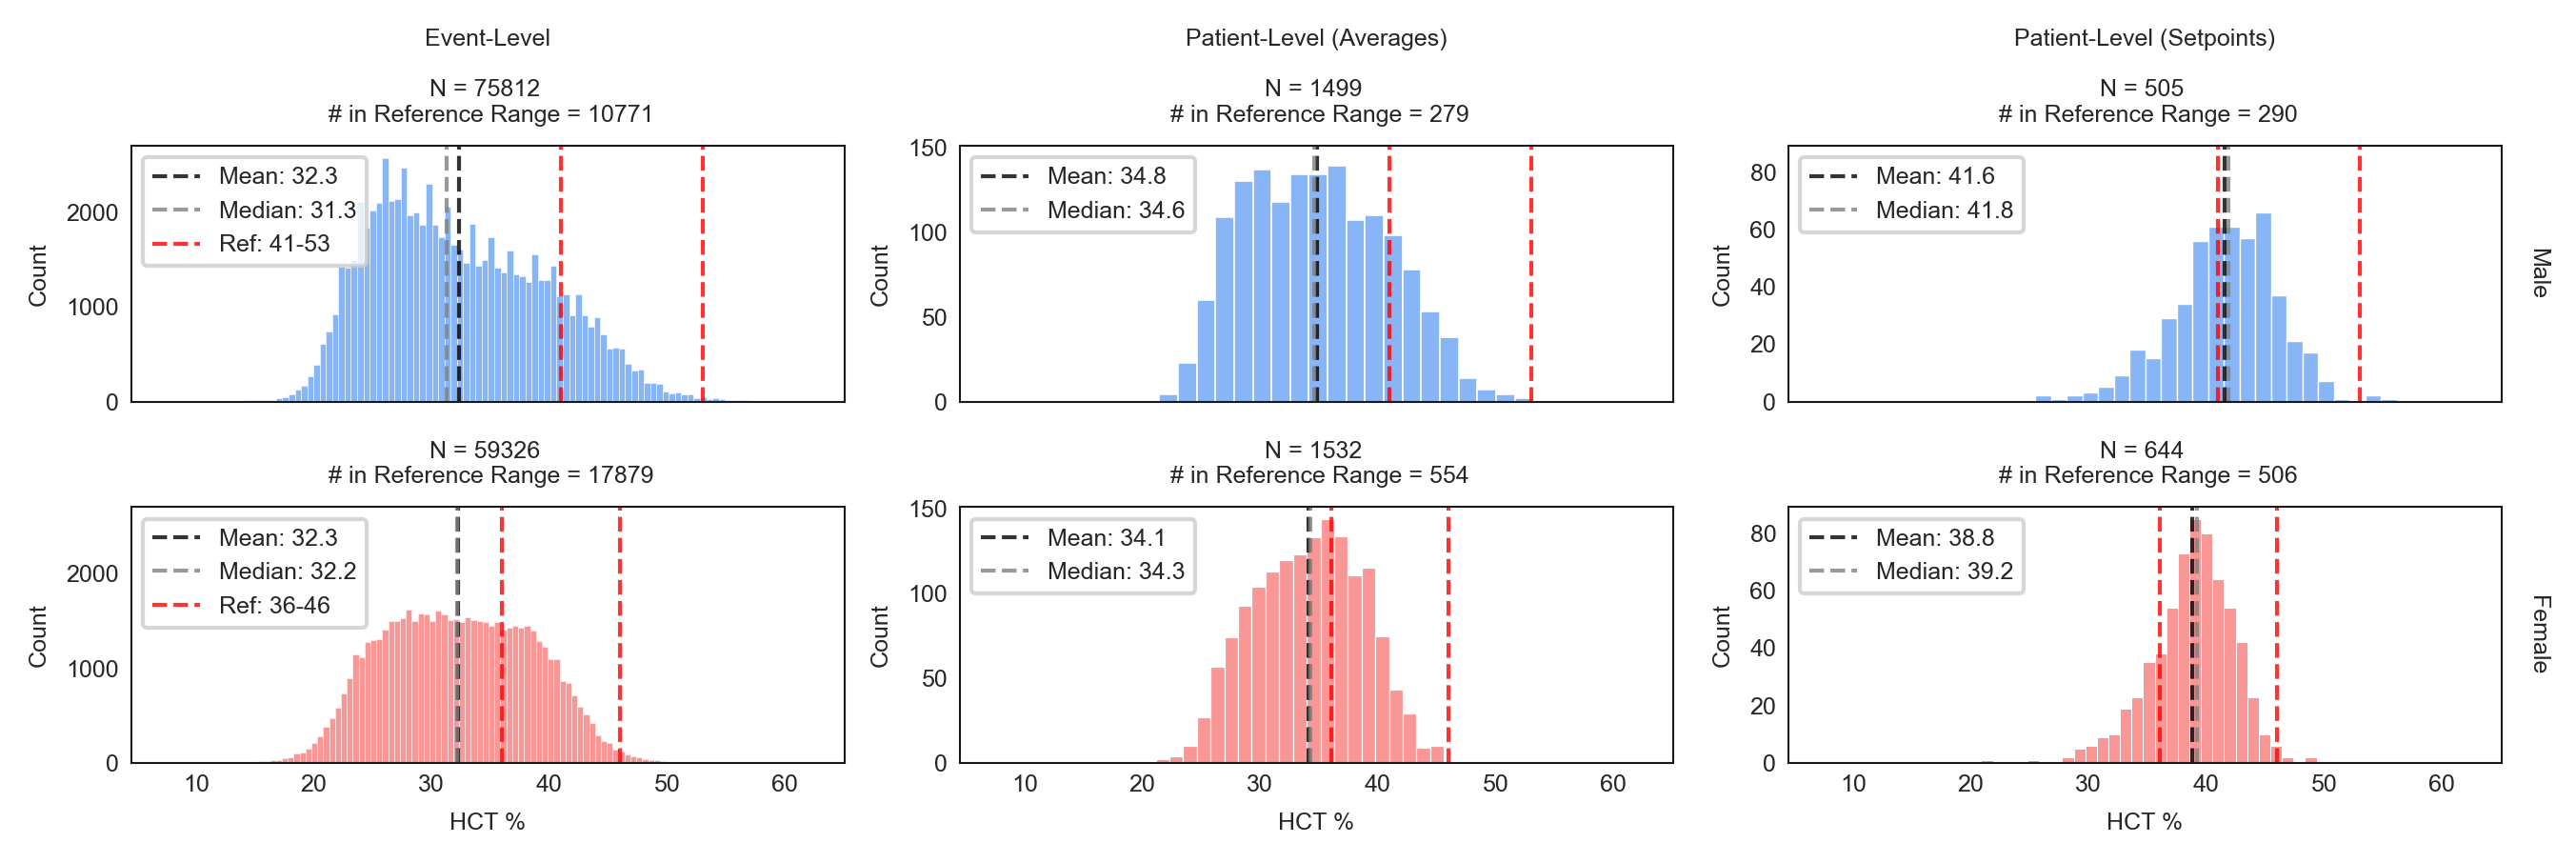

('HGB',)
2988


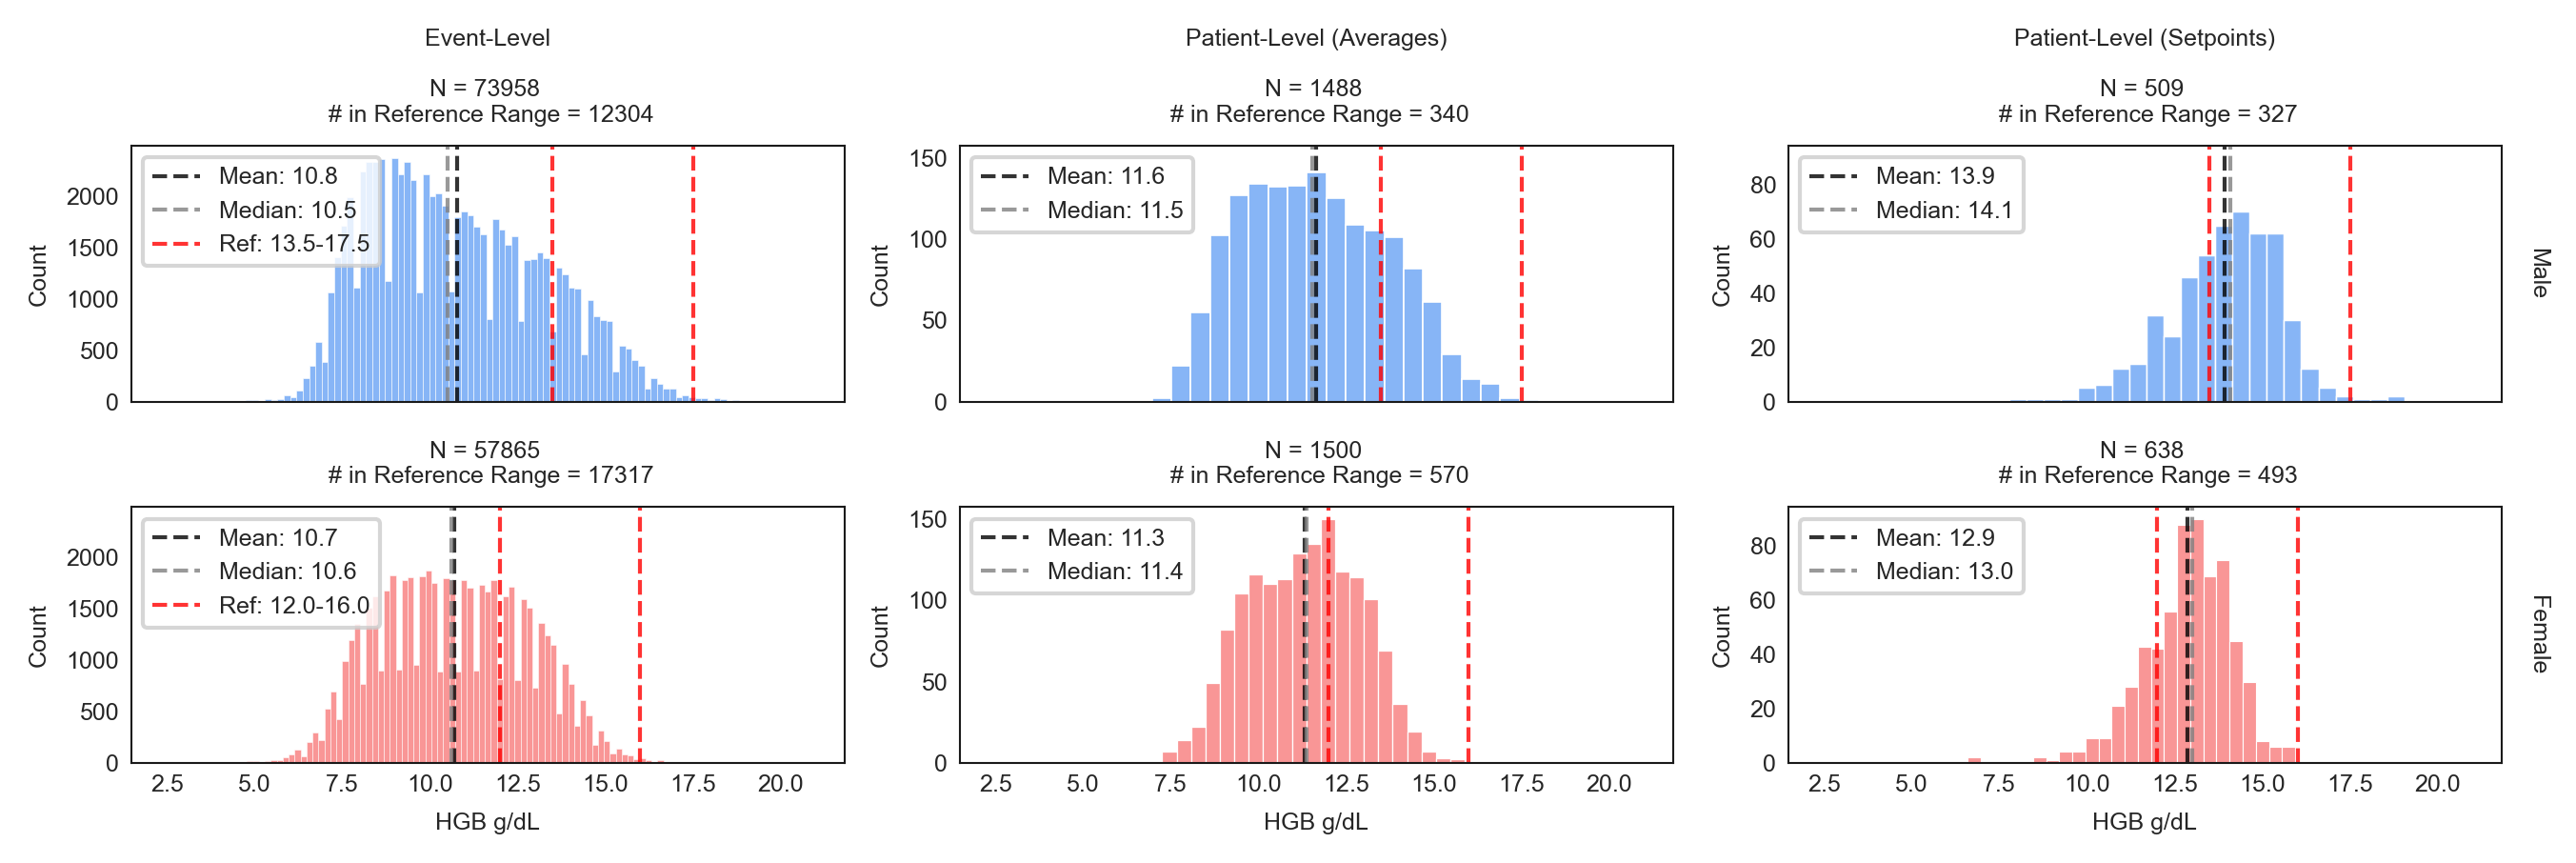

('MCH',)
2949


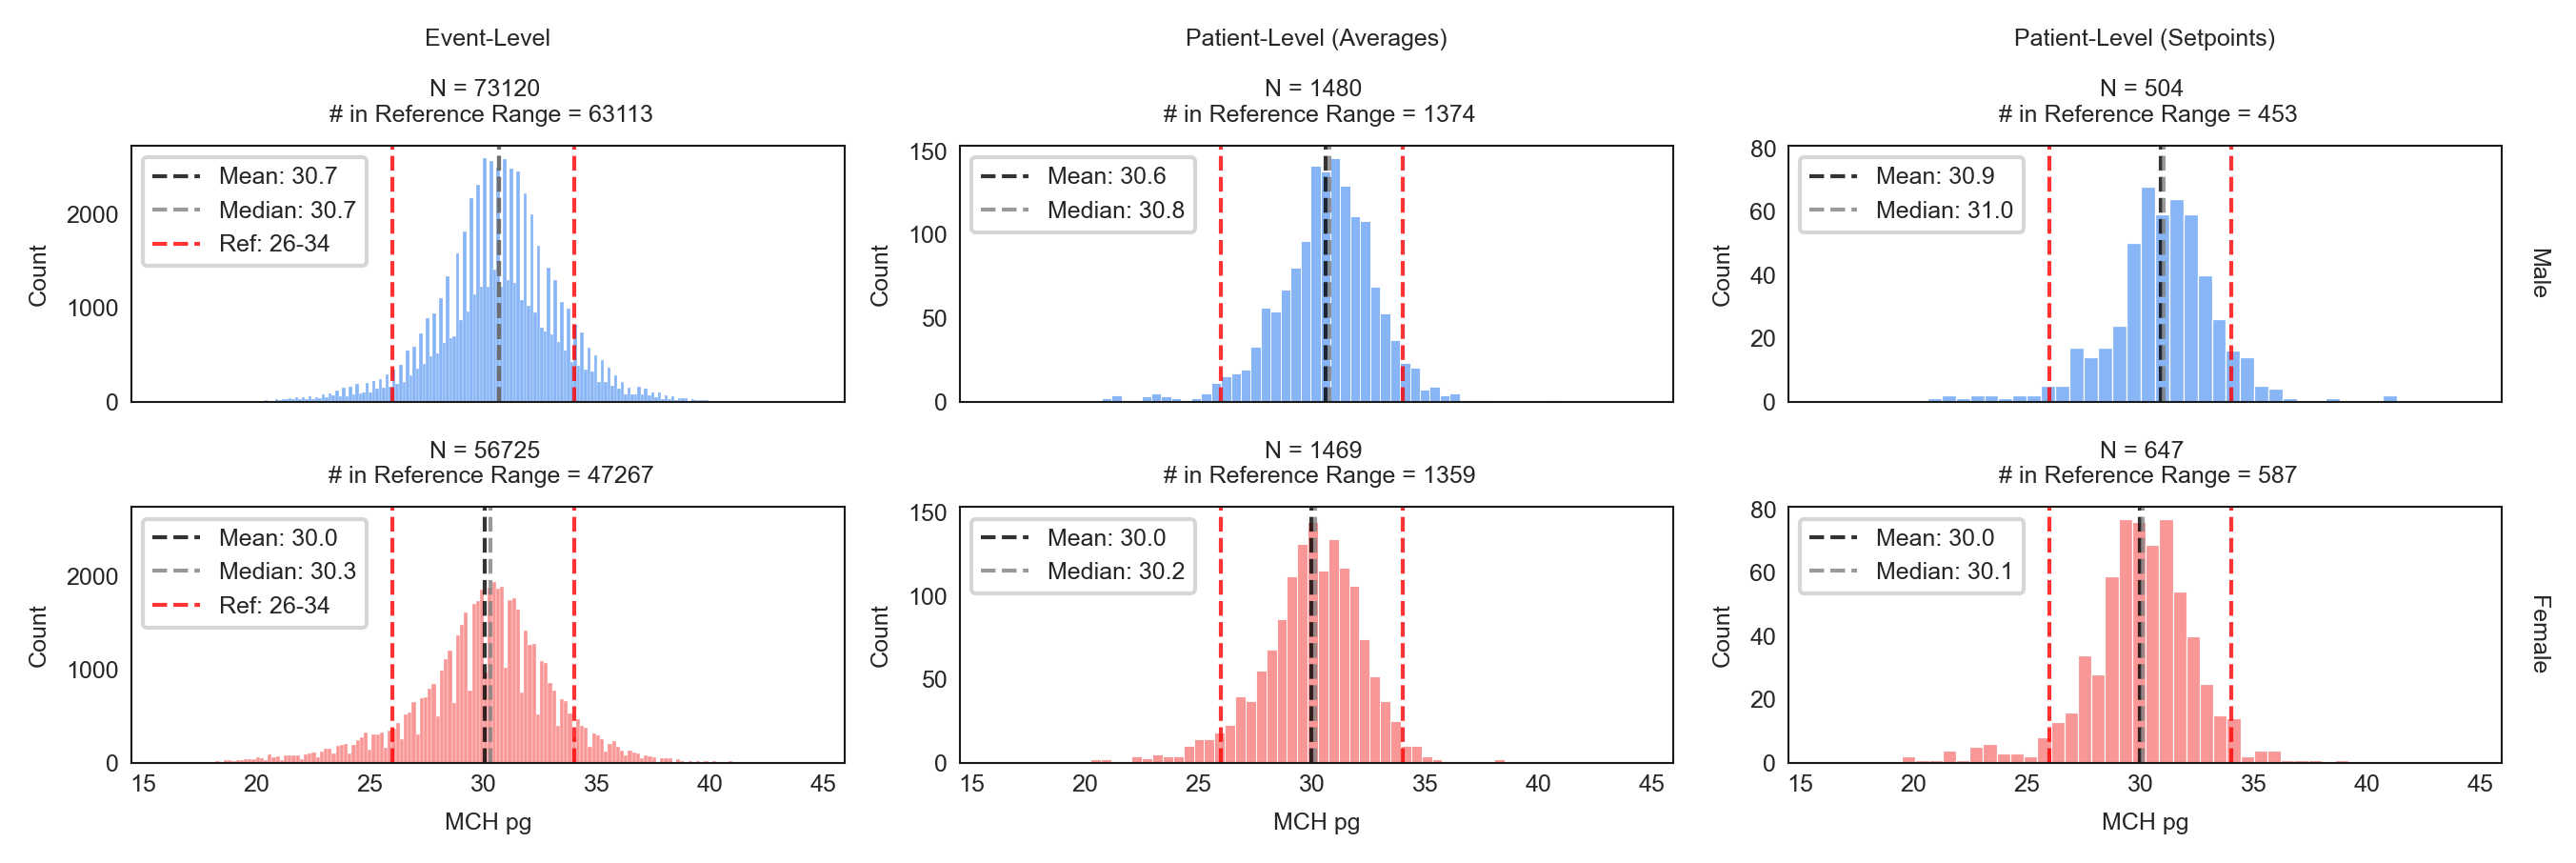

('MCHC',)
2953


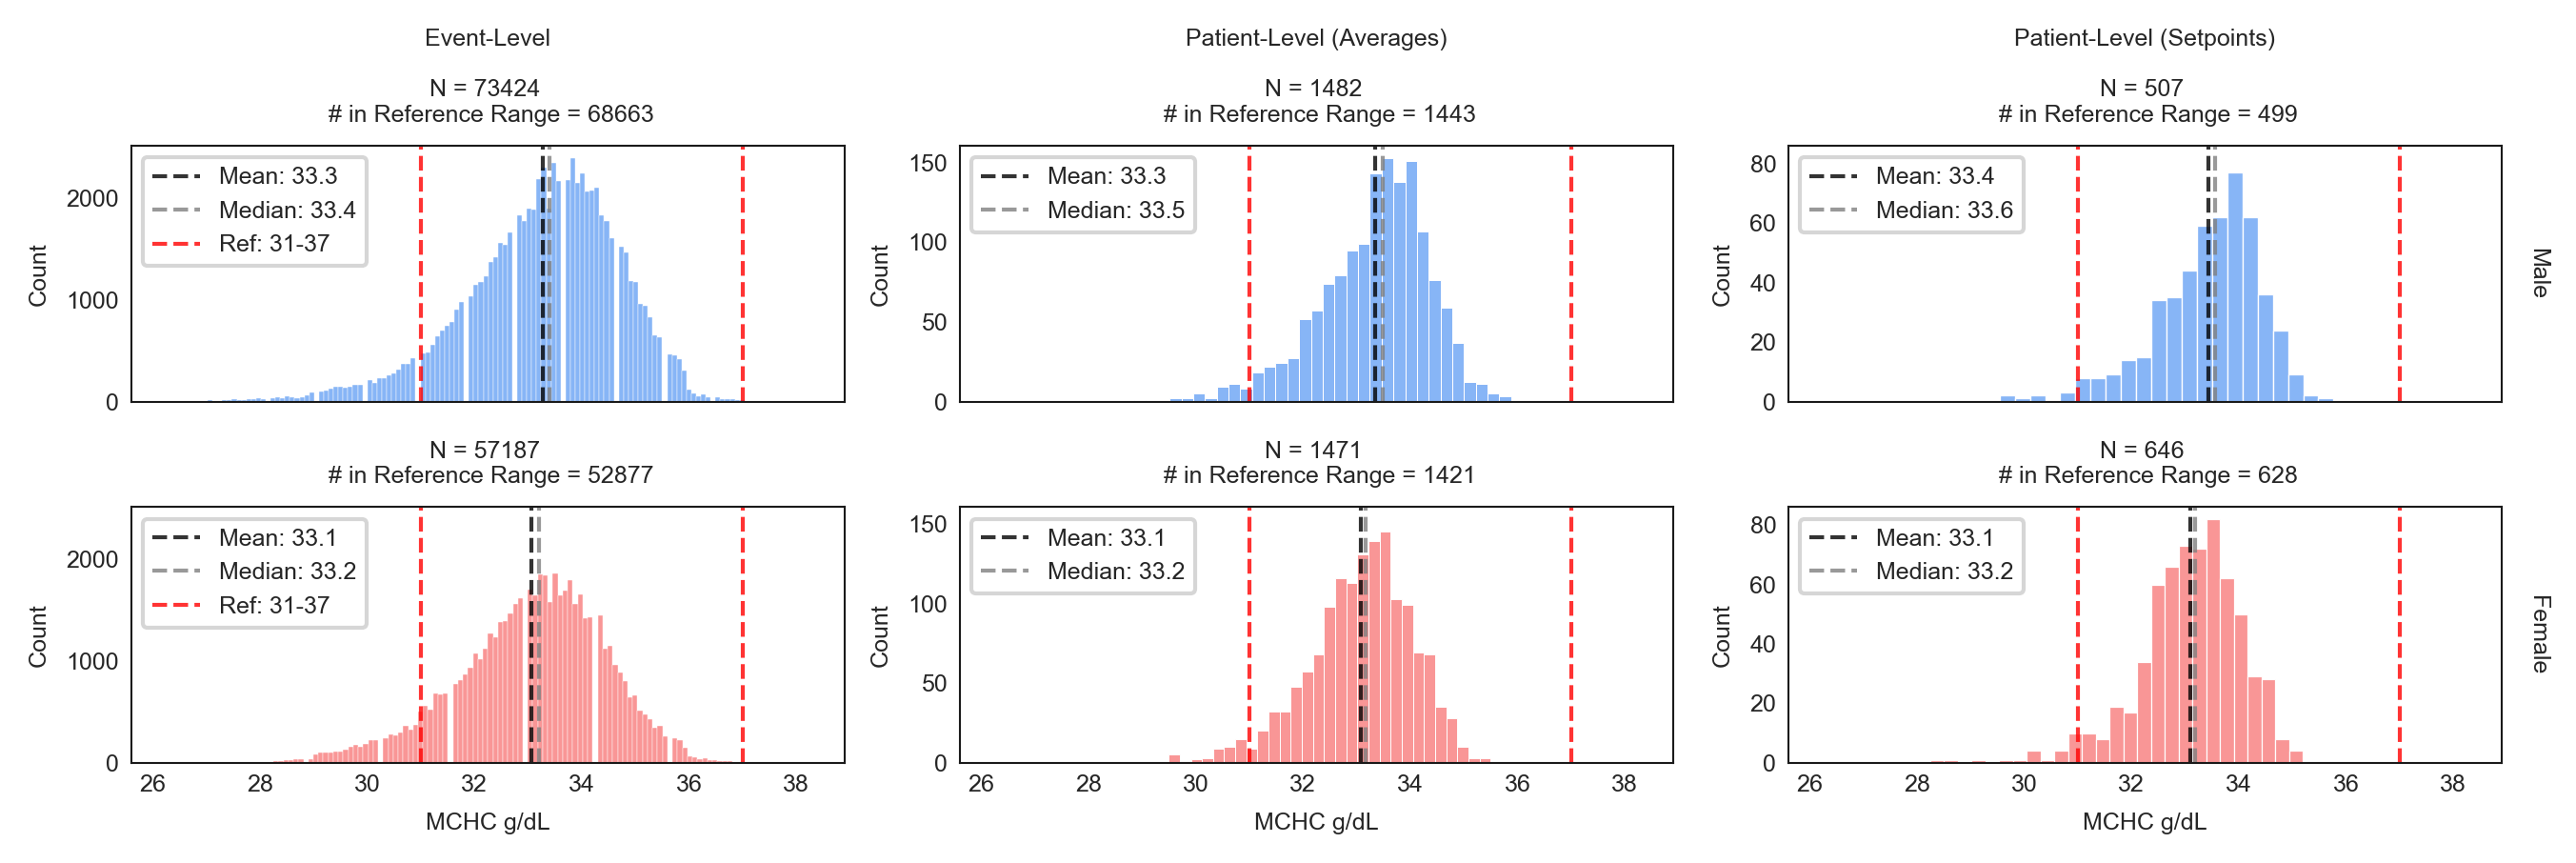

('MCV',)
2954


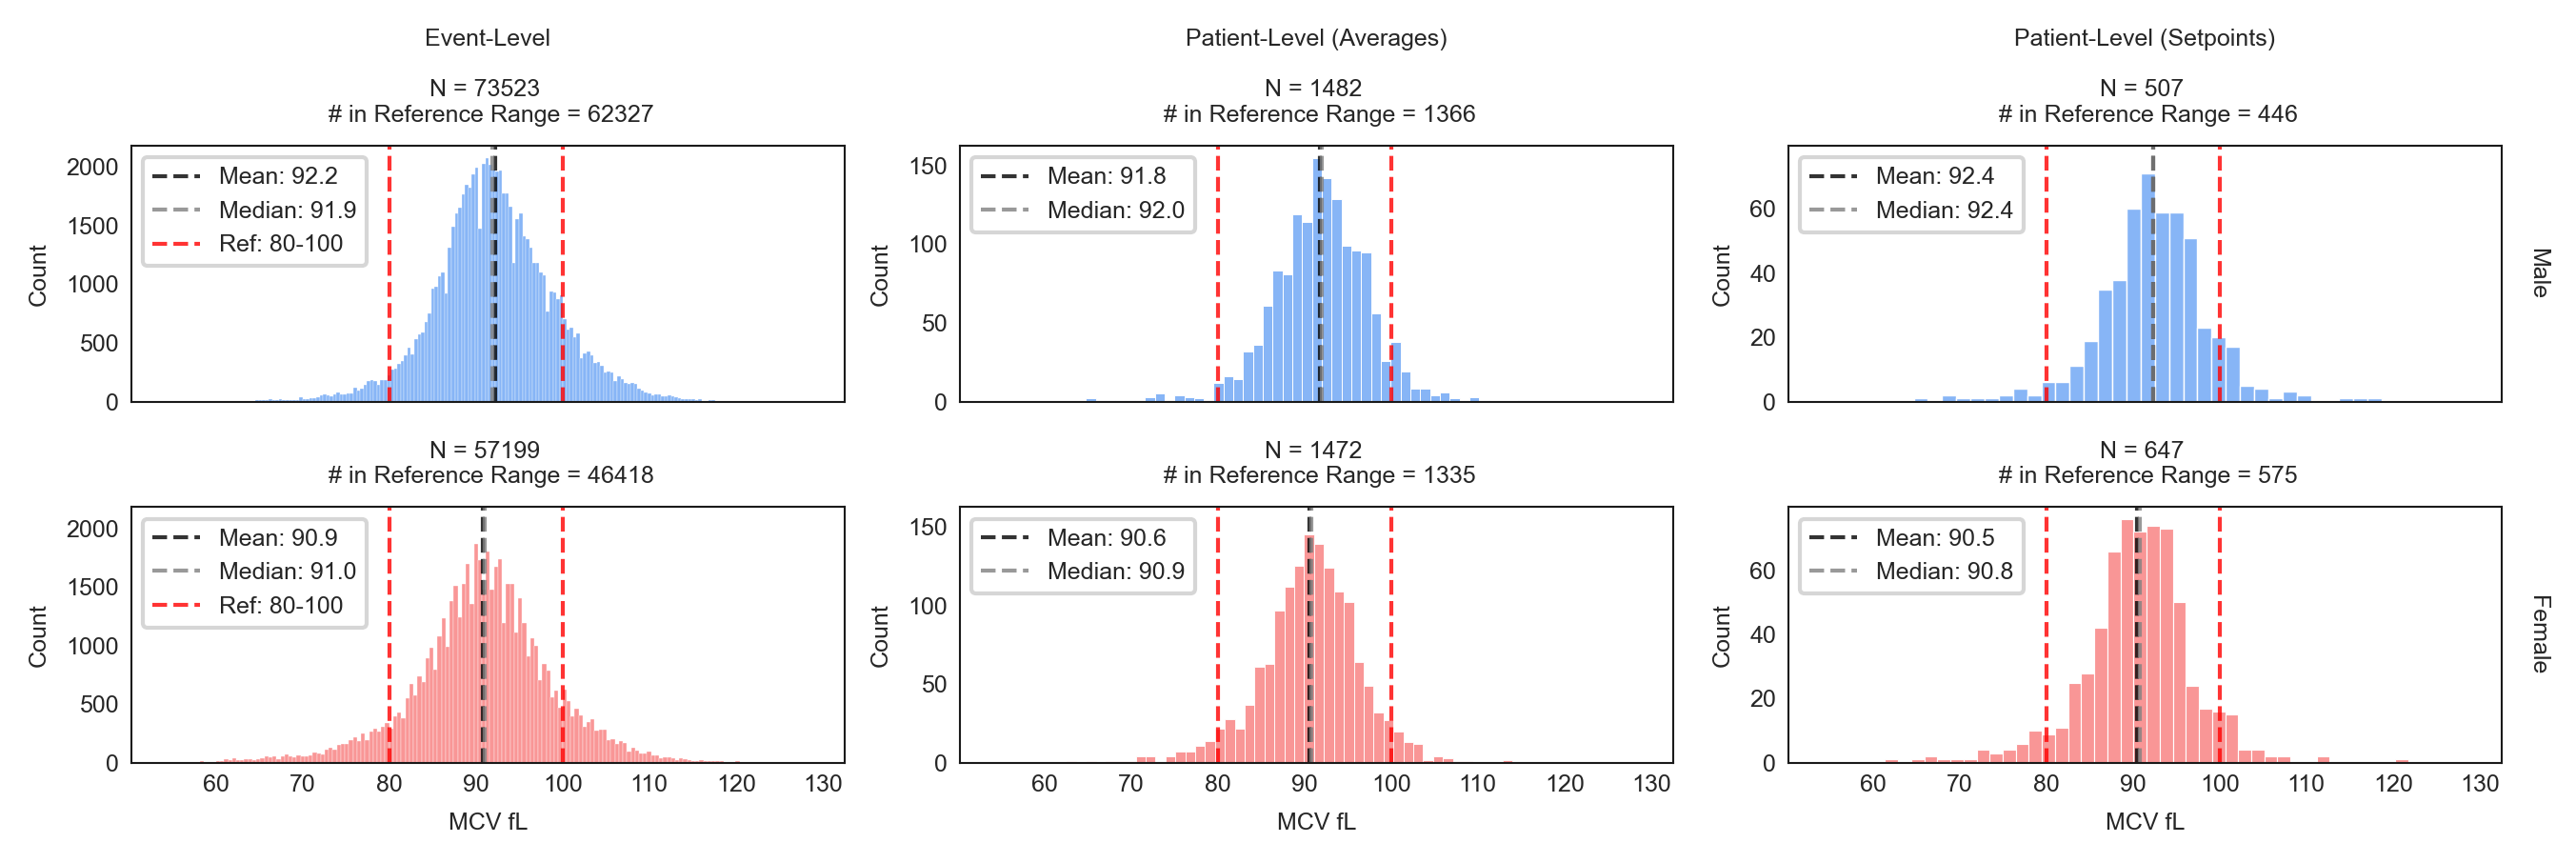

('PLT',)
2966


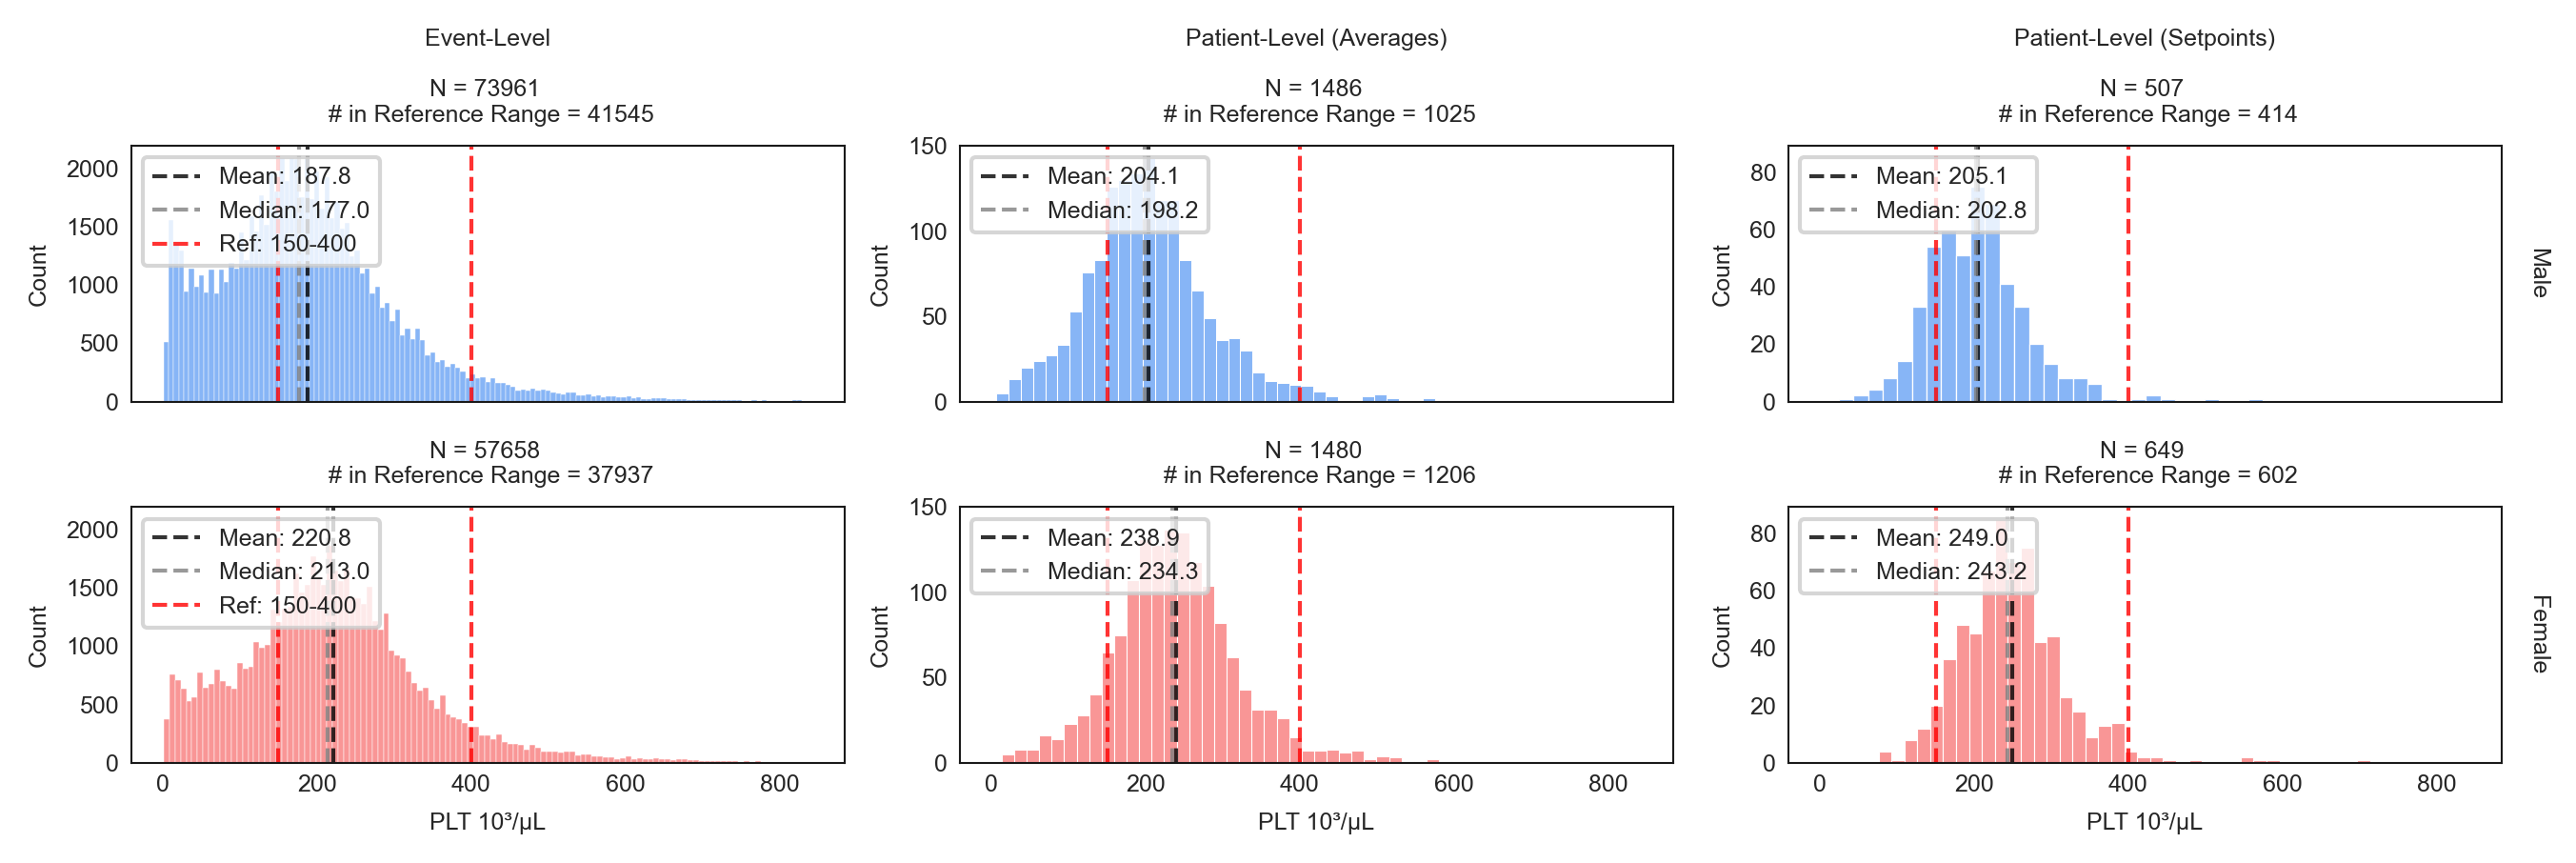

('RBC',)
2954


/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_6165/2511783664.py:111: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aashnashah/opt/anaconda3/envs/setpoints/lib/python3.13/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


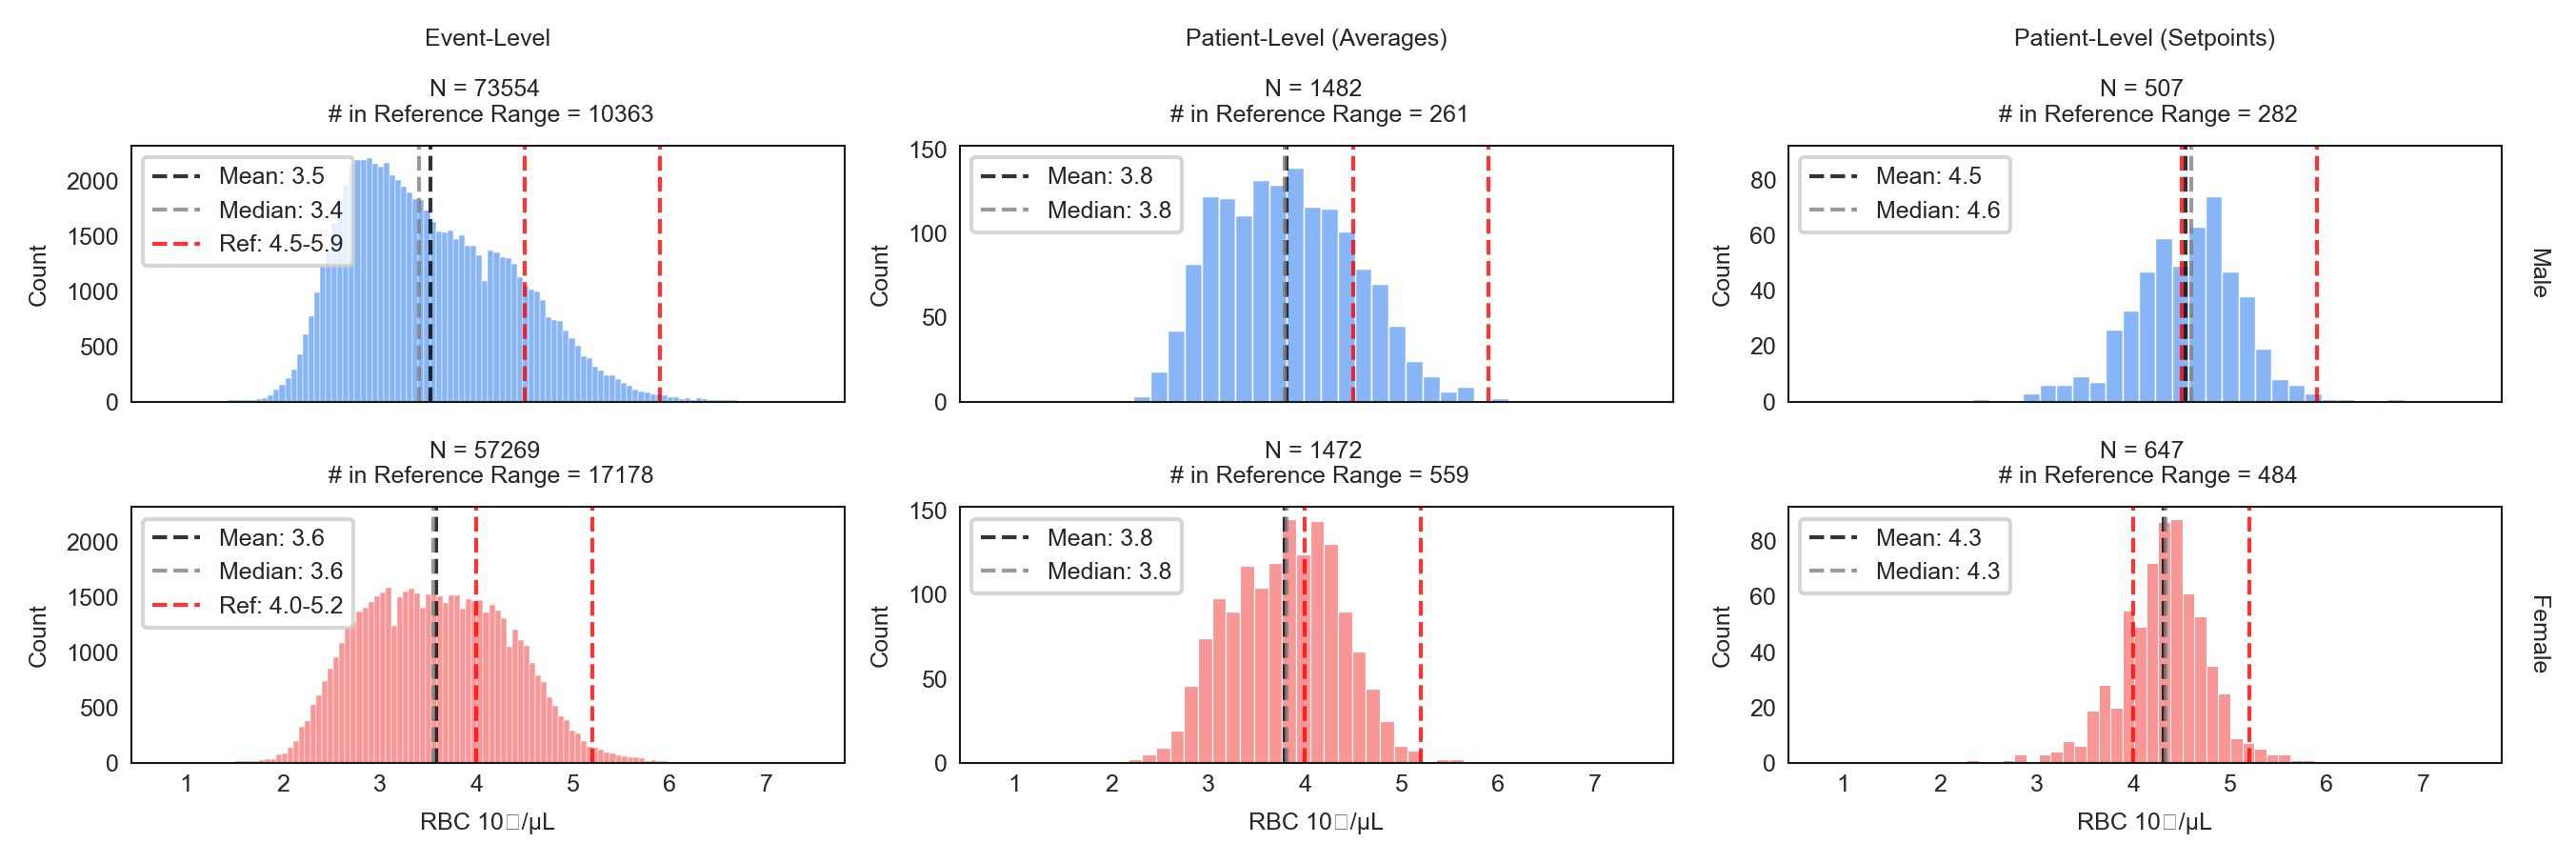

('RDW',)
2954


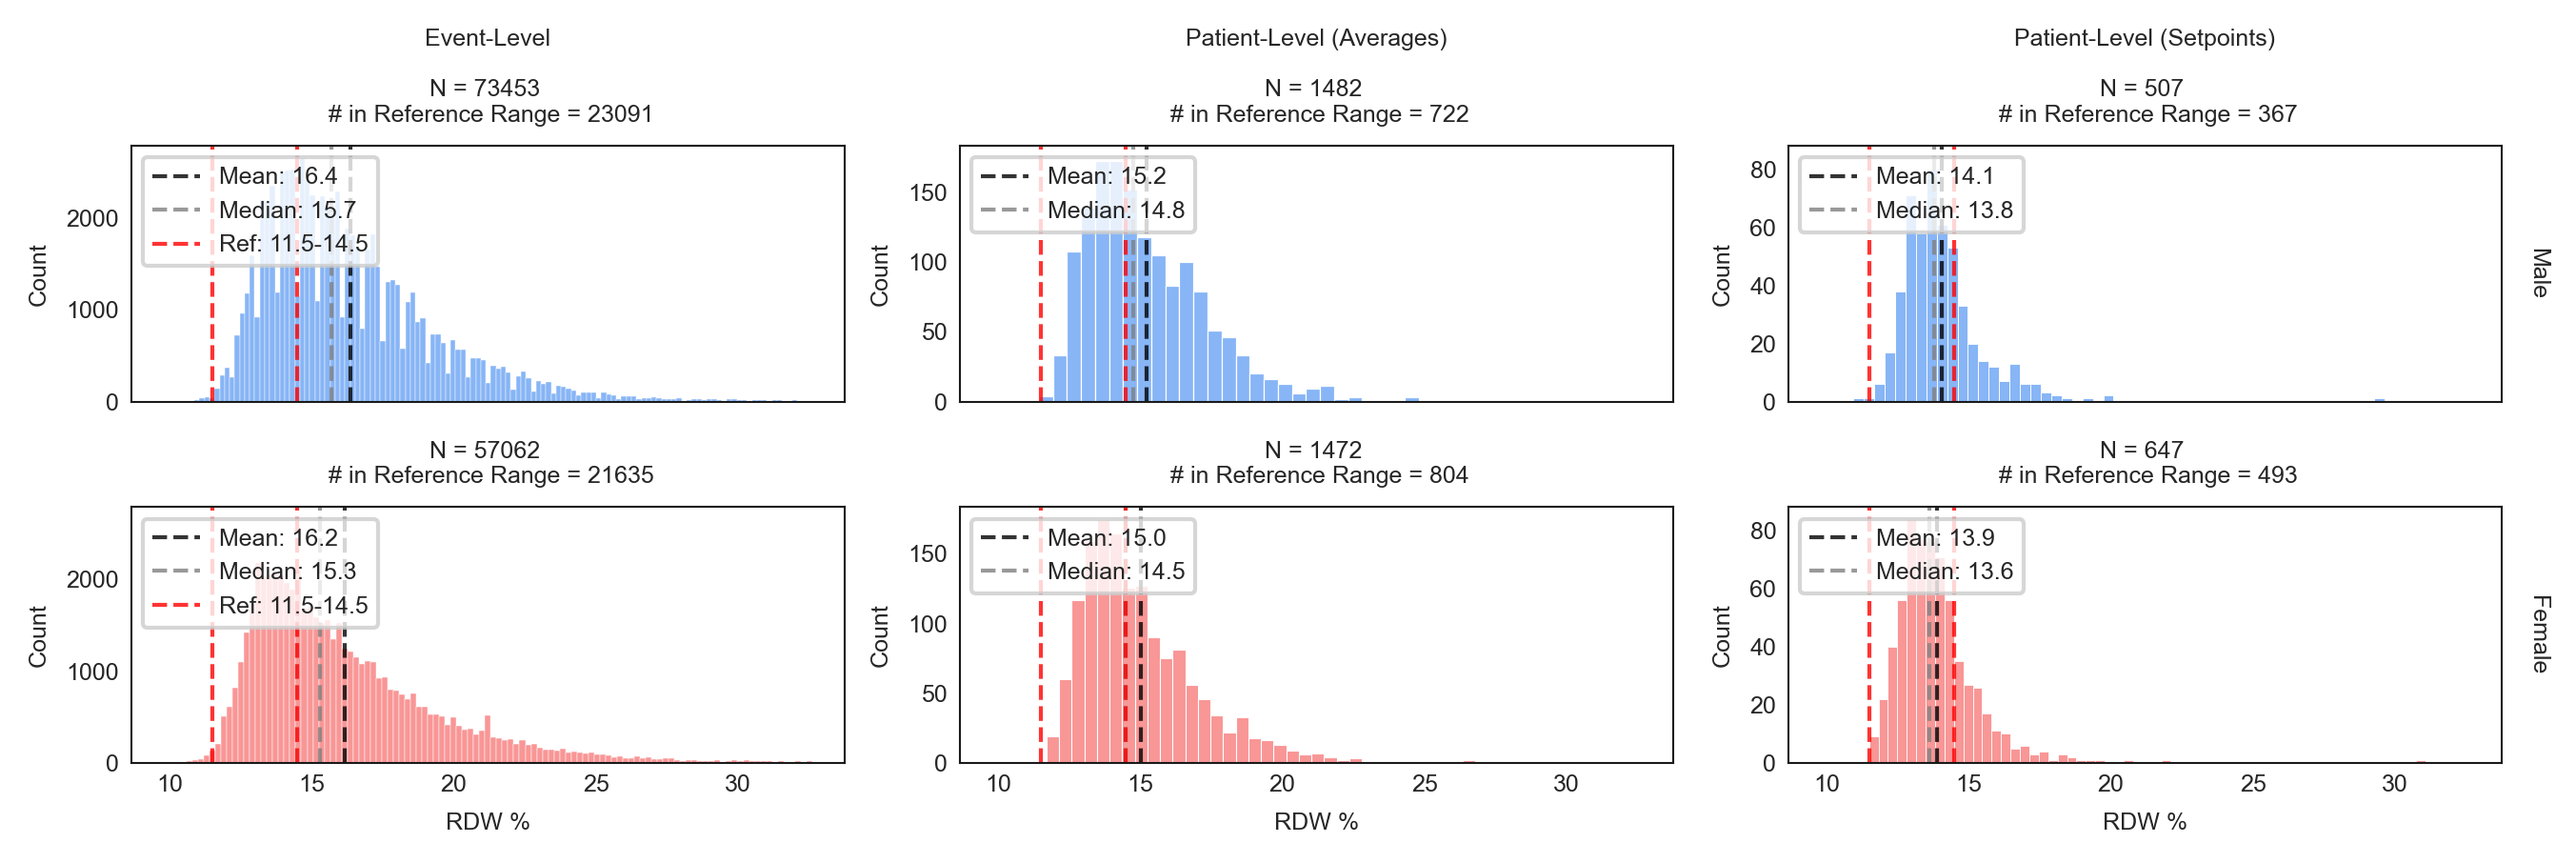

('WBC',)
78


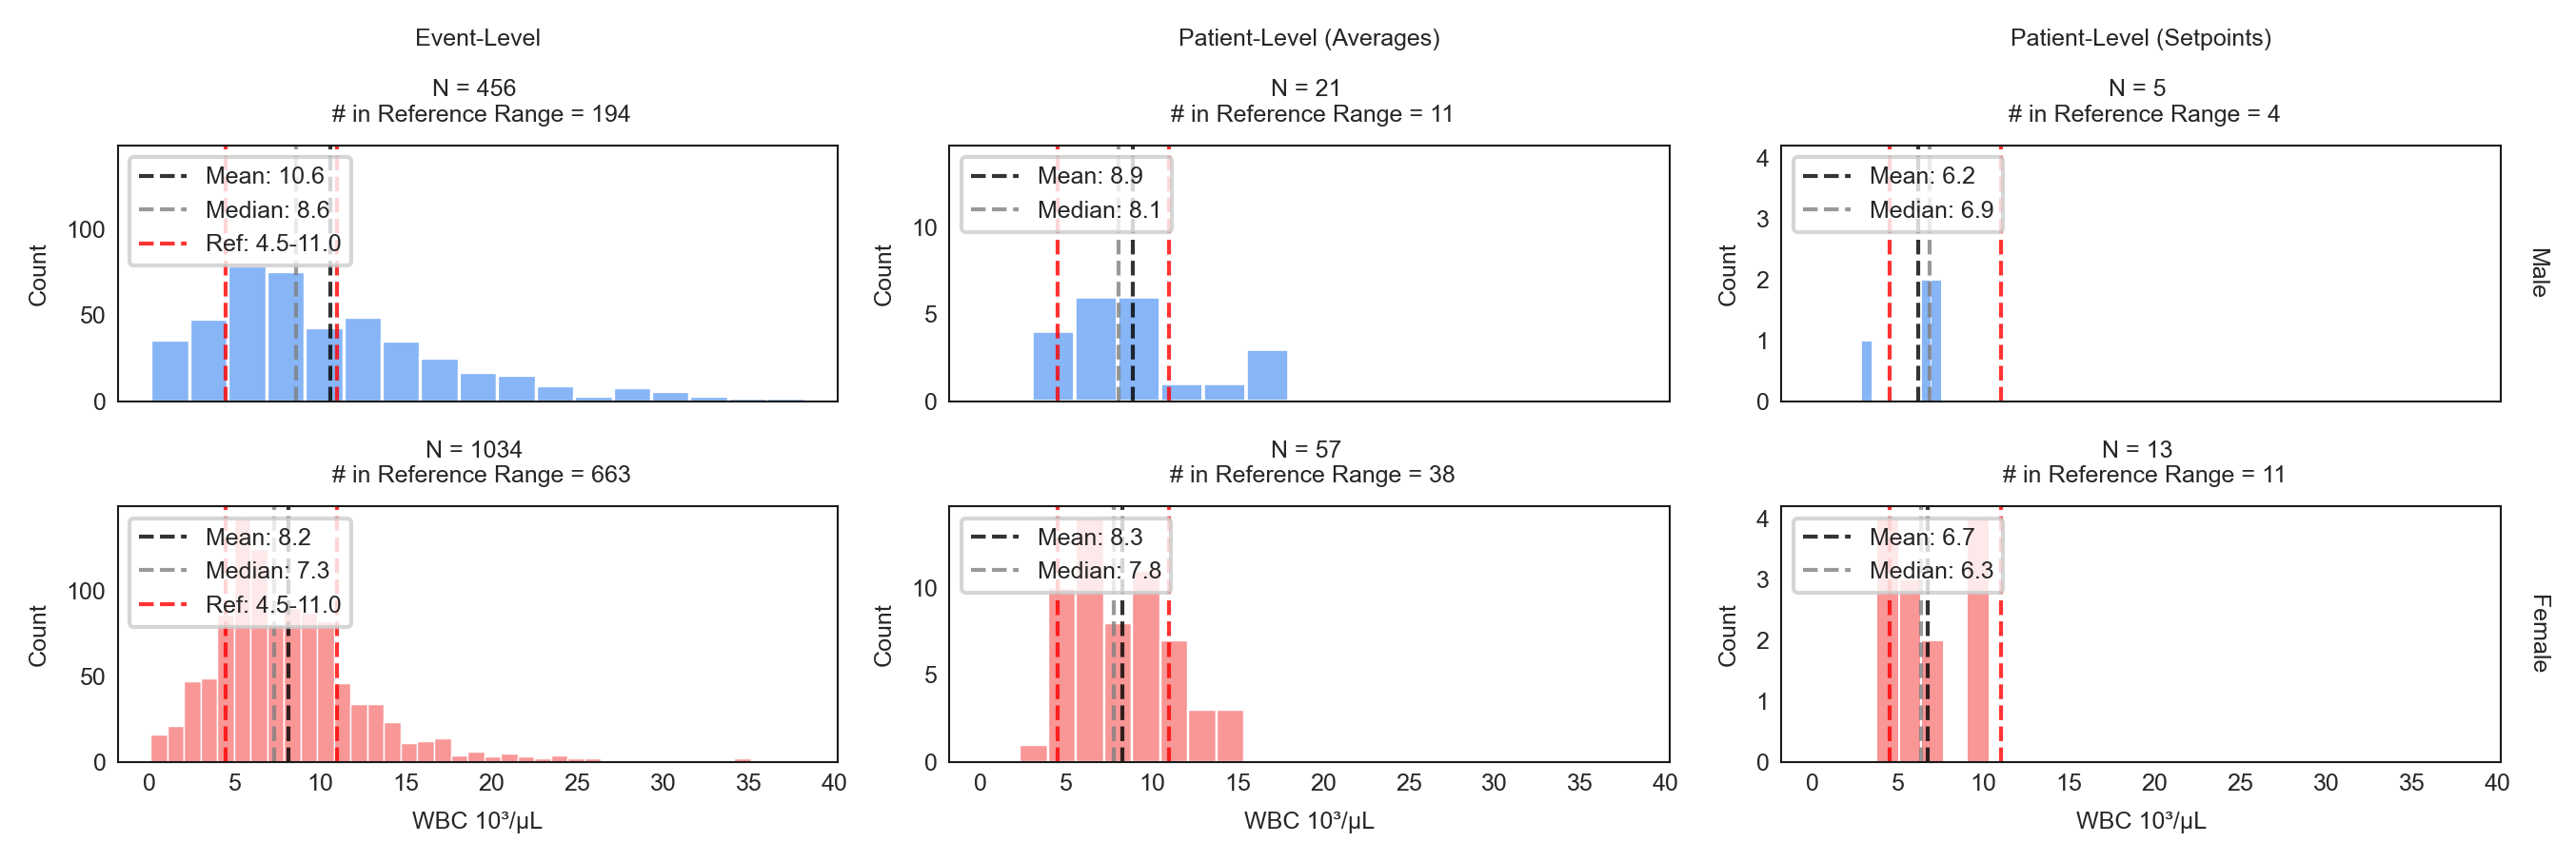

In [126]:
for group, group_df in df.groupby(['code']):
    print(group)
    print(len(group_df.subject_id.unique()))
    cbc_analyze_variable(group_df, setpoint_df, 'numeric_value', group[0])
    plt.tight_layout()
    plt.show()

In [47]:
 # remove the % sign
setpoint_df.percentage_tests_within_reference = setpoint_df.percentage_tests_within_reference.str.rstrip('%')
setpoint_df.percentage_tests_within_reference.astype(float).mean()

68.6679926375054

In [496]:
for group, group_df in df.groupby(['code']):
    print(group)    
    display(group_df.sort_values(by='numeric_value', ascending=False))

('HCT',)


,subject_id,code,time,unit,numeric_value,within_reference,BMI,BMI_category,Gender,DOB,Race,Ethnicity,Age
856577,115971937,HCT,2020-10-03 19:50:00,%,67.20,False,40.053124,Morbid Obesity,F,1981-03-17 00:00:00,5,Not Hispanic,39.548255
619181,115968648,HCT,2017-03-25 14:00:00,%,66.30,False,25.970508,Overweight,M,1936-03-10 00:00:00,5,Not Hispanic,81.040383
709739,115967142,HCT,2018-10-31 19:40:00,%,62.30,False,37.119999,Severe Obesity,M,1954-10-28 00:00:00,4,Not Hispanic,64.008214
838815,115970521,HCT,2020-07-24 05:31:00,%,62.00,False,42.070000,Morbid Obesity,M,1971-05-22 00:00:00,4,Not Hispanic,49.174538
946823,115971381,HCT,2021-09-29 05:33:00,%,61.70,False,36.301318,Severe Obesity,M,1965-01-31 00:00:00,5,Not Hispanic,56.659822
...,...,...,...,...,...,...,...,...,...,...,...,...,...
793096,115968113,HCT,2019-12-23 13:34:00,%,8.80,False,25.793063,Overweight,M,1946-09-28 00:00:00,5,Not Hispanic,73.234771
191232,115973094,HCT,2010-02-11 17:50:00,%,7.90,False,32.950048,Obesity,F,1941-11-05 00:00:00,2,Not Hispanic,68.268309
1028364,115970230,HCT,2022-10-11 18:41:00,%,7.80,False,26.706712,Overweight,M,1949-12-08 00:00:00,5,Not Hispanic,72.840520
708206,115971992,HCT,2018-10-22 18:25:00,%,7.40,False,19.240000,Normal,F,1967-01-06 00:00:00,2,Not Hispanic,51.791923


('HGB',)


,subject_id,code,time,unit,numeric_value,within_reference,BMI,BMI_category,Gender,DOB,Race,Ethnicity,Age
856578,115971937,HGB,2020-10-03 19:50:00,g/dL,20.9,False,40.053124,Morbid Obesity,F,1981-03-17 00:00:00,5,Not Hispanic,39.548255
619183,115968648,HGB,2017-03-25 14:00:00,g/dL,20.8,False,25.970508,Overweight,M,1936-03-10 00:00:00,5,Not Hispanic,81.040383
709735,115967142,HGB,2018-10-31 19:40:00,g/dL,20.0,False,37.119999,Severe Obesity,M,1954-10-28 00:00:00,4,Not Hispanic,64.008214
709318,115967142,HGB,2018-10-29 13:21:00,g/dL,19.9,False,39.500000,Severe Obesity,M,1954-10-28 00:00:00,4,Not Hispanic,64.002738
757344,115969648,HGB,2019-07-08 14:18:00,g/dL,19.9,False,17.545554,Underweight,M,1996-07-25 00:00:00,5,Hispanic,22.951403
...,...,...,...,...,...,...,...,...,...,...,...,...,...
708200,115971992,HGB,2018-10-22 18:25:00,g/dL,2.7,False,19.240000,Normal,F,1967-01-06 00:00:00,2,Not Hispanic,51.791923
327040,115969760,HGB,2012-03-26 14:35:00,g/dL,2.7,False,30.910000,Obesity,M,1946-11-11 00:00:00,5,Not Hispanic,65.371663
191234,115973094,HGB,2010-02-11 17:50:00,g/dL,2.5,False,32.950048,Obesity,F,1941-11-05 00:00:00,2,Not Hispanic,68.268309
1028369,115970230,HGB,2022-10-11 18:41:00,g/dL,2.4,False,26.706712,Overweight,M,1949-12-08 00:00:00,5,Not Hispanic,72.840520


('MCH',)


...

,subject_id,code,time,unit,numeric_value,within_reference,BMI,BMI_category,Gender,DOB,Race,Ethnicity,Age
856572,115971937,RBC,2020-10-03 19:50:00,Million/uL,8.18,False,40.053124,Morbid Obesity,F,1981-03-17 00:00:00,5,Not Hispanic,39.548255
63954,115971585,RBC,2006-12-26 16:05:00,Million/uL,7.47,False,20.580000,Normal,M,1973-06-13 00:00:00,2,Not Hispanic,33.535934
76043,115971585,RBC,2007-09-16 14:15:00,Million/uL,7.38,False,20.580000,Normal,M,1973-06-13 00:00:00,2,Not Hispanic,34.258727
769401,115971585,RBC,2019-09-11 07:22:00,Million/uL,7.36,False,24.340000,Normal,M,1973-06-13 00:00:00,2,Not Hispanic,46.245038
659018,115971585,RBC,2017-12-12 08:11:00,Million/uL,7.25,False,23.704779,Normal,M,1973-06-13 00:00:00,2,Not Hispanic,44.498289
...,...,...,...,...,...,...,...,...,...,...,...,...,...
327042,115969760,RBC,2012-03-26 14:35:00,Million/uL,0.95,False,30.910000,Obesity,M,1946-11-11 00:00:00,5,Not Hispanic,65.371663
708201,115971992,RBC,2018-10-22 18:25:00,Million/uL,0.91,False,19.240000,Normal,F,1967-01-06 00:00:00,2,Not Hispanic,51.791923
191230,115973094,RBC,2010-02-11 17:50:00,Million/uL,0.87,False,32.950048,Obesity,F,1941-11-05 00:00:00,2,Not Hispanic,68.268309
577191,115973778,RBC,2016-07-14 09:29:00,Million/uL,0.86,False,22.459999,Normal,F,1995-05-16 00:00:00,3,Not Hispanic,21.163587


('RDW',)


,subject_id,code,time,unit,numeric_value,within_reference,BMI,BMI_category,Gender,DOB,Race,Ethnicity,Age
814218,115970912,RDW,2020-03-30 00:32:00,%,57.7,False,30.813838,Obesity,M,1982-08-01 00:00:00,5,Not Hispanic,37.661875
426620,115969719,RDW,2014-01-03 16:00:00,%,42.1,False,25.480699,Overweight,F,1980-01-01 00:00:00,2,Not Hispanic,34.006845
639849,115969719,RDW,2017-07-28 04:15:00,%,42.0,False,21.817673,Normal,F,1980-01-01 00:00:00,2,Not Hispanic,37.571526
639888,115969719,RDW,2017-07-28 08:36:00,%,41.6,False,21.817673,Normal,F,1980-01-01 00:00:00,2,Not Hispanic,37.571526
598834,115969719,RDW,2016-11-11 14:53:00,%,41.3,False,22.360001,Normal,F,1980-01-01 00:00:00,2,Not Hispanic,36.862423
...,...,...,...,...,...,...,...,...,...,...,...,...,...
575977,115972109,RDW,2016-07-07 14:08:00,%,10.2,False,26.925556,Overweight,M,1941-06-07 00:00:00,3,Not Hispanic,75.082820
555429,115972033,RDW,2016-02-17 11:14:00,%,10.0,False,30.842983,Obesity,F,1964-01-18 00:00:00,3,Not Hispanic,52.082136
575079,115972109,RDW,2016-07-02 13:18:00,%,10.0,False,26.925556,Overweight,M,1941-06-07 00:00:00,3,Not Hispanic,75.069131
132574,115969000,RDW,2009-01-29 12:20:00,%,9.8,False,20.689615,Normal,F,1955-10-21 00:00:00,2,Not Hispanic,53.275838


('WBC',)


,subject_id,code,time,unit,numeric_value,within_reference,BMI,BMI_category,Gender,DOB,Race,Ethnicity,Age
800536,115971772,WBC,2020-01-21 07:53:00,/uL,40900.0,False,30.878673,Obesity,F,1972-09-05 00:00:00,5,Not Hispanic,47.375770
800422,115971772,WBC,2020-01-20 13:00:00,/uL,36100.0,False,30.878673,Obesity,F,1972-09-05 00:00:00,5,Not Hispanic,47.373032
750476,115972853,WBC,2019-06-06 04:01:00,/uL,24600.0,False,28.608105,Overweight,M,1956-10-10 00:00:00,5,Not Hispanic,62.652977
750679,115972853,WBC,2019-06-07 03:30:00,/uL,24200.0,False,28.608105,Overweight,M,1956-10-10 00:00:00,5,Not Hispanic,62.655715
659207,115971286,WBC,2017-12-13 11:06:00,/uL,22000.0,False,26.780001,Overweight,M,1973-10-04 00:00:00,5,Not Hispanic,44.191650
...,...,...,...,...,...,...,...,...,...,...,...,...,...
460155,115973346,WBC,2014-07-27 10:20:00,K/uL,0.1,False,26.549999,Overweight,M,1992-10-17 00:00:00,5,Not Hispanic,21.774127
460307,115973346,WBC,2014-07-28 10:00:00,K/uL,0.1,False,27.360001,Overweight,M,1992-10-17 00:00:00,5,Not Hispanic,21.776865
460509,115973346,WBC,2014-07-29 11:20:00,K/uL,0.1,False,27.230000,Overweight,M,1992-10-17 00:00:00,5,Not Hispanic,21.779603
460902,115973346,WBC,2014-08-01 08:15:00,K/uL,0.1,False,27.620001,Overweight,M,1992-10-17 00:00:00,5,Not Hispanic,21.787817
